# 05 Links to Other Indices

Compares the DPI against two external benchmarks:
1. Official FIA Championship Standings - Spearman rank correlation per season
2. OpenF1 lap telemetry - average gap to session fastest lap as an 
   independent pace metric for 2023 and 2024



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

norm_df = pd.read_csv(PROCESSED_DIR / 'dpi_final.csv')

print("Shape:", norm_df.shape)
print("\nColumns:", list(norm_df.columns))

Shape: (105, 24)

Columns: ['season', 'driver_id', 'driver_code', 'driver_name', 'constructor', 'races', 'total_points', 'points_per_race', 'avg_finish_position', 'finish_position_std', 'wins', 'podiums', 'dnfs', 'dnf_rate', 'avg_positions_gained', 'points_finish_rate', 'avg_quali_position', 'cluster', 'cluster_label', 'DPI', 'DPI_rank', 'official_rank', 'DPI_rank_season', 'rank_diff']


## Part 1: DPI vs Official FIA Championship Standings

The Spearman rank correlation coefficient measures how closely the DPI 
ranking agrees with the official FIA championship ranking each season. 
A value of 1 means perfect agreement, 0 means no relationship. 
Spearman is used rather than Pearson because we are comparing ranks 
rather than raw values.

In [3]:
results = []
for season in sorted(norm_df['season'].unique()):
    season_data = norm_df[norm_df['season'] == season].dropna()
    r, p = spearmanr(
        season_data['official_rank'],
        season_data['DPI_rank_season']
    )
    results.append({
        'season'    : season,
        'spearman_r': round(r, 3),
        'p_value'   : round(p, 4),
        'n_drivers' : len(season_data)
    })

spearman_df = pd.DataFrame(results)
print("Spearman Correlation — DPI vs Official FIA Standings:")
print(spearman_df.to_string(index=False))

Spearman Correlation — DPI vs Official FIA Standings:
 season  spearman_r  p_value  n_drivers
   2021       0.959      0.0         20
   2022       0.919      0.0         20
   2023       0.936      0.0         22
   2024       0.894      0.0         22
   2025       0.906      0.0         21


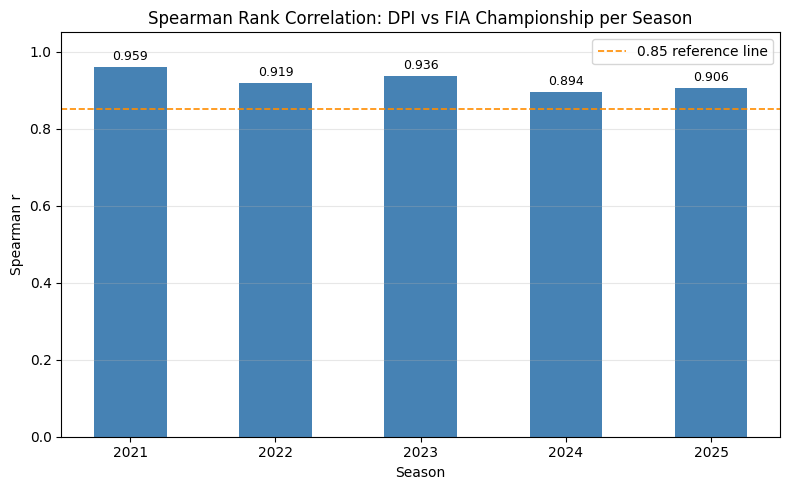

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    spearman_df['season'],
    spearman_df['spearman_r'],
    color='steelblue', width=0.5
)
ax.axhline(0.85, linestyle='--', color='darkorange',
           linewidth=1.2, label='0.85 reference line')
ax.set_ylim(0, 1.05)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_title('Spearman Rank Correlation: DPI vs FIA Championship per Season')
ax.set_xlabel('Season')
ax.set_ylabel('Spearman r')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'spearman_by_season.png', dpi=150)
plt.show()

## DPI vs Official Rank Scatter Plot

Visualises where DPI rank and official rank agree and where they diverge.
Points on the diagonal line represent perfect agreement. Points above 
the line mean the DPI ranks that driver higher than the official standings.

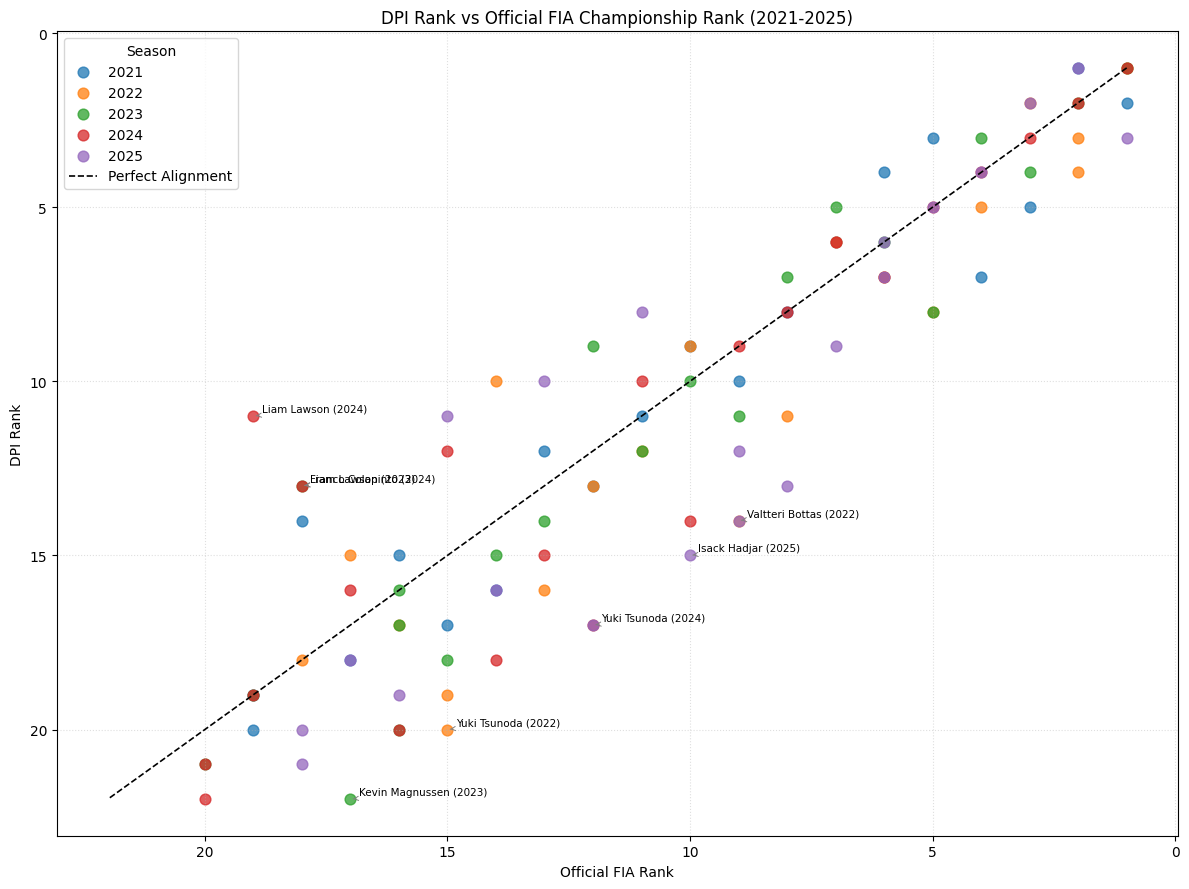

In [5]:
norm_df['abs_diff'] = norm_df['rank_diff'].abs()
top_outliers = norm_df.nlargest(8, 'abs_diff')

season_colors = {
    2021: '#1f77b4', 2022: '#ff7f0e',
    2023: '#2ca02c', 2024: '#d62728', 2025: '#9467bd'
}

fig, ax = plt.subplots(figsize=(12, 9))

for season, group in norm_df.groupby('season'):
    ax.scatter(
        group['official_rank'],
        group['DPI_rank_season'],
        label=str(season),
        color=season_colors.get(season, 'grey'),
        alpha=0.75, s=60
    )

for _, row in top_outliers.iterrows():
    ax.annotate(
        f"{row['driver_name']} ({int(row['season'])})",
        (row['official_rank'], row['DPI_rank_season']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=7.5,
        arrowprops=dict(arrowstyle='->', color='grey', lw=0.7)
    )

max_r = int(max(norm_df['official_rank'].max(),
                norm_df['DPI_rank_season'].max()))
ax.plot([1, max_r], [1, max_r], 'k--', linewidth=1.2,
        label='Perfect Alignment')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title('DPI Rank vs Official FIA Championship Rank (2021-2025)')
ax.set_xlabel('Official FIA Rank')
ax.set_ylabel('DPI Rank')
ax.legend(title='Season')
ax.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_vs_official_rank.png', dpi=150)
plt.show()

In [6]:
print("Top 8 largest DPI vs FIA rank divergences:")
print(
    top_outliers[['season', 'driver_name', 'constructor',
                  'official_rank', 'DPI_rank_season', 'rank_diff']]
    .sort_values('rank_diff', key=abs, ascending=False)
    .to_string(index=False)
)

Top 8 largest DPI vs FIA rank divergences:
 season      driver_name  constructor  official_rank  DPI_rank_season  rank_diff
   2024      Liam Lawson   RB F1 Team           19.0             11.0        8.0
   2022  Valtteri Bottas   Alfa Romeo            9.0             14.0       -5.0
   2022     Yuki Tsunoda   AlphaTauri           15.0             20.0       -5.0
   2023  Kevin Magnussen Haas F1 Team           17.0             22.0       -5.0
   2023      Liam Lawson   AlphaTauri           18.0             13.0        5.0
   2024 Franco Colapinto     Williams           18.0             13.0        5.0
   2024     Yuki Tsunoda   RB F1 Team           12.0             17.0       -5.0
   2025     Isack Hadjar   RB F1 Team           10.0             15.0       -5.0


## Part 2 - OpenF1 Telemetry Validation

OpenF1 provides lap-level telemetry data independent of the Jolpica 
dataset. The metric used is average gap to the session fastest lap 
expressed as a percentage, a lower gap means faster pace. This gives 
a completely independent cross-check on whether DPI rankings agree 
with raw lap time performance.

Coverage is limited to 2023 and 2024 as OpenF1 data before 2023 
is incomplete.

In [11]:
import requests
import time

OPENF1_BASE        = 'https://api.openf1.org/v1'
VALIDATION_SEASONS = [2023, 2024]

def openf1_get(endpoint, params=None):
    url      = f"{OPENF1_BASE}/{endpoint}"
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    time.sleep(0.3)
    return response.json()

session_rows = []
for year in VALIDATION_SEASONS:
    sessions = openf1_get('sessions',
                          params={'year': year, 'session_type': 'Race'})
    for s in sessions:
        if not s.get('is_cancelled', False) and s['session_name'] == 'Race':
            session_rows.append({
                'session_key' : s['session_key'],
                'race_name'   : s['country_name'],
                'year'        : s['year']
            })

sessions_df = pd.DataFrame(session_rows)
print(f"Found {len(sessions_df)} race sessions")
print(sessions_df.groupby('year').size())

Found 46 race sessions
year
2023    22
2024    24
dtype: int64
